In [28]:
# Import Packages
import os
import re
import sys
import time
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import holoviews as hv
import pandas as pd

import xarray as xr
import hvplot.pandas
import hvplot.xarray

#sys.path.append('../')
sys.path.append('EMIT-Data-Resources/python/modules/')

from emit_tools import emit_xarray

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [2]:
import earthaccess

#earthaccess.login(persist=True)
auth = earthaccess.login()
if not auth.authenticated:
    # ask for credentials and persist them in a .netrc file
    auth.login(strategy="interactive", persist=True)

/opt/anaconda3/envs/bkos/lib/python3.14/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


Enter your Earthdata Login username:  kosarajub_1978
Enter your Earthdata password:  ········


In [3]:
results = earthaccess.search_data(short_name="EMITL2ARFL", count=1)
print(len(results))

1


/opt/anaconda3/envs/bkos/lib/python3.14/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


In [4]:
def safe_norm_diff(a, b):
    if pd.isna(a) or pd.isna(b) or (a + b) == 0:
        return np.nan
    return (a - b) / (a + b)

def safe_ratio(a, b):
    if pd.isna(a) or pd.isna(b) or b == 0:
        return np.nan
    return a / b

# EMIT Data

**NASA Earth Data**  
https://nasa-openscapes.github.io/2023-Cloud-Workshop-AGU/tutorials/Earthdata_Search_Discovery_earthaccess.html

**EMIT**  
 - https://earth.jpl.nasa.gov/emit/
 - https://www.earthdata.nasa.gov/data/instruments/emit-imaging-spectrometer

**NASA EMIT USER GUIDE:**  
 - https://lpdaac.usgs.gov/documents/1569/EMITL2ARFL_User_Guide_v1.pdf?utm_source=chatgpt.com
 - https://www.earthdata.nasa.gov/s3fs-public/2025-06/EMIT_Data_Resources_Poster_2023_AGU_ck_approved.pdf?VersionId=rGIZ6MbeRP68HEGWCRInda2qzHGK7LNv

**Unified Metadata Model (UMM)**  
https://www.earthdata.nasa.gov/about/esdis/eosdis/cmr/umm

**Some examples:**  
https://github.com/nasa/EMIT-Data-Resources/blob/main/python/how-tos/How_to_find_and_access_EMIT_data.ipynb

### NETCDF FILE
A NetCDF file is a self-describing scientific data file format commonly used for Earth observation data. 

**A NetCDF file stores both:**  
 - The data arrays themselves
 - Metadata describing dimensions, coordinates, variable names, units, and structure.

For EMIT L2A reflectance, the NetCDF reflectance file stores a 285-band surface reflectance cube plus geolocation-related information.  

### GRANULE  
 - A granule is one packaged EMIT observation unit returned by NASA Earthdata search.  
 - In practice, it is one EMIT scene/product instance for a particular place/time, not the whole mission archive.  
 - Each granule is roughly ~75 km × 75 km.

**Each EMIT granule contains three NetCDF files:**  
 - **Reflectance NetCDF (EMIT_L2A_RFL):**  Contains surface reflectance maps  
 - **Mask NetCDF (EMIT_L2A_MASK):** Contains atmospheric state estimates and binary flags
 - **Uncertainty NetCDF (EMIT_L2A_RFLUNCERT):** Contains uncertainty estimates and  

**A reflectance file contains**:  
 - 285 bands spanning wavelengths of between 381 and 2493 nm with a spatial resolution of ~60 m
 - Latitude
 - Longitude
 - Elevation
 - Geolocation lookup tables

**A mask file contains flags like**:  
 - Clouds
 - Water
 - Invalid pixels

## QUERY NASA EARTH DATA.

**BOUNDING BOX FOR THE DATA POINTS**  
**Determine a bounding box that covers a set of points on a map.**  
Suppose your group has these three points:  
 - point 1: longitude = -89.2, latitude = 13.7  
 - point 2: longitude = -89.0, latitude = 13.8  
 - point 3: longitude = -88.8, latitude = 13.9  
Determine a small rectangle that contains all of the above points.  

A bounding box is defined by four numbers:
 - minimum longitude = left edge  
 - minimum latitude  = bottom edge  
 - maximum longitude = right edge  
 - maximum latitude  = top edge  

**Padding**
If an exact tight box is used, we may miss relevant granules because:  
 - A point may lie very close to the edge  
 - Floating point or geolocation precision may cause small mismatches  
So padding is a safety margin.  
Example: pad_deg=0.01 => Expanding by ~1 km on each side of the bounding box rectange.

In [5]:
def build_group_bounding_box(df_group, pad_deg=0.01):
    lon_min = df_group["longitude"].min() - pad_deg
    lon_max = df_group["longitude"].max() + pad_deg
    lat_min = df_group["latitude"].min() - pad_deg
    lat_max = df_group["latitude"].max() + pad_deg
    return (lon_min, lat_min, lon_max, lat_max)

**QUERY NASA**
Use **earthaccess.search_data** to find all of the the EMIT granules:  
 - whose acquisition time intersects the target date range, and
 - whose footprint intersects the desired bounding box.”

In [6]:
def parse_granule_datetime(granule):
    # Try common earthaccess/CMR structures in order
    candidates = []

    # 1. Granule.meta
    try:
        meta = granule.meta
        if isinstance(meta, dict):
            candidates.append(meta)
    except Exception:
        pass

    # 2. Granule.umm
    try:
        umm = granule.umm
        if isinstance(umm, dict):
            candidates.append(umm)
    except Exception:
        pass

    # 3. Granule as dict-like
    try:
        if isinstance(granule, dict):
            candidates.append(granule)
    except Exception:
        pass

    # Search for datetime in common fields
    for obj in candidates:
        # Direct flat keys
        for key in ["BeginningDateTime", "beginningDateTime", "TemporalExtent"]:
            val = obj.get(key)
            if isinstance(val, str):
                ts = pd.to_datetime(val, errors="coerce")
                if not pd.isna(ts):
                    return ts

        # UMM-style nested structure
        tr = obj.get("TemporalExtent", {}).get("RangeDateTime", {})
        val = tr.get("BeginningDateTime")
        if val:
            ts = pd.to_datetime(val, errors="coerce")
            if not pd.isna(ts):
                return ts

        # Sometimes nested under 'umm'
        umm = obj.get("umm", {})
        tr = umm.get("TemporalExtent", {}).get("RangeDateTime", {})
        val = tr.get("BeginningDateTime")
        if val:
            ts = pd.to_datetime(val, errors="coerce")
            if not pd.isna(ts):
                return ts

    return pd.NaT

In [7]:
def extract_emit_spectra_in_granule(nc_path, df_points):
    # Extract EMIT reflectance spectra for each point in df_points from a single granule.
    # DataFrame in long format with columns row_id, wavelengths, reflectance

    # ortho=True aligns the dataset to lat/lon coordinates
    ds = emit_xarray(nc_path, ortho=True)

    """
    # Print the coordinate grid for debugging
    print(f"  ds latitude  range: {float(ds.latitude.min()):.5f} to {float(ds.latitude.max()):.5f}")
    print(f"  ds longitude range: {float(ds.longitude.min()):.5f} to {float(ds.longitude.max()):.5f}")
    print(f"  ds latitude  shape: {ds.latitude.shape}")
    print(f"  ds longitude shape: {ds.longitude.shape}")
    print(f"  ds latitude  unique values: {len(np.unique(ds.latitude.values))}")
    print(f"  ds longitude unique values: {len(np.unique(ds.longitude.values))}")
    """
    row = df_points.iloc[0]
    sub = ds.sel(latitude=row['latitude'], longitude=row['longitude'], method='nearest')

    """
    print("Sample data point")
    print(f"  Requested : ({row['latitude']:.5f}, {row['longitude']:.5f})")
    print(f"  Selected  : ({float(sub.latitude.values):.5f}, {float(sub.longitude.values):.5f})")
    print(f"  Reflectance sample: {sub['reflectance'].values[:5]}")
    """

    # One EMIT pixel is ~60 meters.
    # At the equator 60m ≈ 0.000540 degrees.
    # We allow up to 1.5x pixel width as tolerance to account for
    # grid alignment offsets while still rejecting true out-of-footprint snaps.
    EMIT_PIXEL_DEG = 0.000540
    TOLERANCE_DEG  = EMIT_PIXEL_DEG * 1.5

    results         = []
    skipped_count   = 0

    for _, row in df_points.iterrows():
        requested_lat = row["latitude"]
        requested_lon = row["longitude"]

        # Find nearest pixel in the granule grid
        sub = ds.sel(
            latitude=requested_lat,
            longitude=requested_lon,
            method="nearest"
        )

        # Check how far the selected pixel is from the requested point
        actual_lat = float(sub.latitude.values)
        actual_lon = float(sub.longitude.values)

        lat_diff = abs(actual_lat - requested_lat)
        lon_diff = abs(actual_lon - requested_lon)

        if lat_diff > TOLERANCE_DEG or lon_diff > TOLERANCE_DEG:
            """
            print(f"    Skipping row_id={row['row_id']} — "
                  f"requested ({requested_lat:.5f}, {requested_lon:.5f}) "
                  f"nearest pixel ({actual_lat:.5f}, {actual_lon:.5f}) "
                  f"distance ({lat_diff:.6f} deg lat, {lon_diff:.6f} deg lon) "
                  f"exceeds tolerance {TOLERANCE_DEG:.6f} deg")
            """
            skipped_count += 1
            continue

        sub_df = sub.to_dataframe().reset_index()
        
        # Filter nodata sentinel
        EMIT_NODATA = -9999.0
        sub_df = sub_df[sub_df['reflectance'] != EMIT_NODATA]
        
        if sub_df.empty:
            #print(f"    Skipping row_id={row['row_id']} — all reflectance values are nodata")
            skipped_count += 1
            continue
    
        sub_df["row_id"] = row["row_id"]
        results.append(sub_df)

    """
    if skipped_count > 0:
        print(f"    Skipped {skipped_count} of {len(df_points)} points — outside granule footprint")
    """

    if not results:
        return pd.DataFrame()

    extracted = pd.concat(results, ignore_index=True)

    # Filter to good wavelengths only
    if "good_wavelengths" in extracted.columns:
        extracted = extracted[extracted["good_wavelengths"] == 1].copy()

    return extracted

In [8]:
def extract_all_bands(long_df):
    # Convert long-format EMIT spectra into wide format:
    # one row per row_id, one column per wavelength reflectance.

    if long_df.empty:
        return pd.DataFrame()

    required_cols = ["row_id", "wavelengths", "reflectance"]
    missing = [c for c in required_cols if c not in long_df.columns]
    if missing:
        raise ValueError(f"long_df missing required columns: {missing}")

    df = long_df[required_cols].copy()

    # Some wavelength values can be floats like 381.0, 388.5, etc.
    # Round slightly for stable column naming.
    df["wavelengths"] = df["wavelengths"].astype(float).round(0).astype(int)

    # Pivot wavelengths into columns
    wide_df = df.pivot_table(
        index="row_id",
        columns="wavelengths",
        values="reflectance",
        aggfunc="first"
    ).reset_index()

    # Separate row_id and wavelength columns
    wavelength_cols = [c for c in wide_df.columns if c != "row_id"]
    # Sort wavelength columns numerically
    wavelength_cols_sorted = sorted(wavelength_cols)
    # Reorder: row_id first, then wavelengths
    wide_df = wide_df[["row_id"] + wavelength_cols_sorted]

    # Rename columns into CSV-safe names
    # Example: 381.0 -> EMIT_R381, 388.5 -> EMIT_R388
    new_cols = []
    for col in wide_df.columns:
        if col == "row_id":
            new_cols.append("row_id")
        else:
            #col_str = str(col).replace(".", "_")
            #new_cols.append(f"EMIT_R{col_str}")
            new_cols.append(f"EMIT_R{col}")

    wide_df.columns = new_cols
    return wide_df

In [9]:
def granule_covers_point(granule, lat, lon):
    # Check if granule spatial extent actually covers the point.
    try:
        bbox = granule['umm']['SpatialExtent']['HorizontalSpatialDomain'] \
                      ['Geometry']['BoundingRectangles'][0]
        return (bbox['SouthBoundingCoordinate'] <= lat <= bbox['NorthBoundingCoordinate'] and
                bbox['WestBoundingCoordinate']  <= lon <= bbox['EastBoundingCoordinate'])
    except Exception:
        return True  # if metadata missing, allow through and let pixel check catch it

def granule_covers_group(granule, df_group):
    # Return True if granule covers at least one point in the group.
    return any(
        granule_covers_point(granule, row['latitude'], row['longitude'])
        for _, row in df_group.iterrows()
    )

In [10]:
def process_emit_date_group_all_granules(df_group, start_date, end_date, download_dir):
    bbox = build_group_bounding_box(df_group)

    granules = earthaccess.search_data(short_name="EMITL2ARFL",
                                       version="001",
                                       cloud_hosted=True,
                                       temporal=(start_date.strftime("%Y-%m-%d"),
                                                 end_date.strftime("%Y-%m-%d")),
                                       bounding_box=bbox,
                                       count=200)
    print(f" Total Granules found: {len(granules)}")

    # Case 1: No granules found.
    if not granules:
        missing_group = df_group.copy()
        missing_group["missing_reason"] = "no_granules_found"
        return pd.DataFrame(), missing_group

    candidate_rows       = []
    failed_granule_count = 0
    empty_longdf_count   = 0
    empty_featdf_count   = 0

    for granule_idx, granule in enumerate(granules, start=1):
        try:
            print(f"  Processing granule {granule_idx}/{len(granules)}")
            
            # Pre-filter — skip granules that do not cover any point in the group
            if not granule_covers_group(granule, df_group):
                print(f"  Granule {granule_idx} — CMR bbox does not cover any group point, skipping download")
                continue

            # Download granule if needed.
            os.makedirs(download_dir, exist_ok=True)
            start = time.time()
            nc_path = earthaccess.download([granule], download_dir)[0]
            end = time.time()
            print("    Downloaded to .." + str(nc_path))
            print(f"Time taken to download: {end - start:.2f} seconds")
            if nc_path is None:
                print("    Download returned None")
                failed_granule
                continue

            long_df = extract_emit_spectra_in_granule(nc_path, df_group)
            if long_df.empty:
                print("    long_df is empty")
                empty_longdf_count += 1
                continue

            feat_df = extract_all_bands(long_df)
            if feat_df.empty:
                print("    feat_df is empty")
                empty_featdf_count += 1
                continue

            gtime = parse_granule_datetime(granule)
            feat_df["EMIT_selected_date"] = gtime

            # In practice, the NetCDF filename acts as the granule identifier
            granule_id = os.path.basename(nc_path) if nc_path else None
            feat_df["EMIT_granule"] = str(granule_id) if granule_id is not None else np.nan

            feat_df["days_from_start"] = (
                abs((gtime - start_date).total_seconds()) / 86400
                if not pd.isna(gtime) else float("inf")
            )

            candidate_rows.append(feat_df)

        except Exception as e:
            print(f"  Granule failed: {e}")
            failed_granule_count += 1
            #assert 0
            continue

    # Case 2: Granules exist, but none of them are useful.
    if not candidate_rows:
        missing_group = df_group.copy()

        if failed_granule_count == len(granules):
            reason = "all_granules_failed"
        elif empty_longdf_count == len(granules):
            reason = "all_granules_returned_no_points"
        elif empty_featdf_count == len(granules):
            reason = "all_granules_returned_no_features"
        else:
            reason = "no_usable_emit_features"

        missing_group["missing_reason"] = reason
        return pd.DataFrame(), missing_group

    all_candidates = pd.concat(candidate_rows, ignore_index=True)
    all_candidates = all_candidates.sort_values(["row_id", "days_from_start"])

    # Keep closest granule to start_date for each row_id
    best_emit = all_candidates.groupby("row_id", as_index=False).first()
    best_emit = best_emit.drop(columns=["days_from_start"])

    # Output only rows with EMIT data
    merged_group = df_group.merge(best_emit, on="row_id", how="inner")

    # Add original rows whose row_id did not appear in best_emit into missing list.
    found_row_ids = set(best_emit["row_id"].tolist())
    missing_mask  = ~df_group["row_id"].isin(found_row_ids)

    missing_group = df_group.loc[missing_mask].copy()
    missing_group["missing_reason"] = "not_covered_by_selected_granules"

    return merged_group, missing_group

In [11]:
def load_agb_data(csv_file):
    orig_df = pd.read_csv(csv_file)

    # Parse as UTC-aware datetimes
    orig_df['start_date'] = pd.to_datetime(orig_df['start_date'], utc=True, errors='coerce')
    orig_df['end_date']   = pd.to_datetime(orig_df['end_date'], utc=True, errors='coerce')

    # Discard all data that is older than 2020.
    discard_threshold = pd.Timestamp('2020-01-01', tz='UTC')
    mask = (
        (orig_df['start_date'].notna()) &
        (orig_df['start_date'] >= discard_threshold)
    )
    agb_df       = orig_df[mask].copy()
    discarded_df = orig_df[~mask].copy()
    
    agb_df['capture_start'] = agb_df['start_date']
    agb_df['capture_end']   = agb_df['end_date']

    # Timeline of EMIT spectroscopy
    #  July 2022    :  Installed on the International Space Station
    #  Aug–Sept 2022: Commissioning / calibration phase
    #  Late 2022    : Early science data starts
    #  2023 onward  : Regular science operation
    emit_threshold_start = pd.Timestamp('2023-01-01', tz='UTC')
    emit_threshold_end   = pd.Timestamp('2025-12-31', tz='UTC')
    #emit_threshold_end   = pd.Timestamp('2023-06-30', tz='UTC')
    
    mask = agb_df['start_date'] < emit_threshold_start
    agb_df.loc[mask, 'capture_start'] = emit_threshold_start
    agb_df.loc[mask, 'capture_end']   = emit_threshold_end

    return agb_df, discarded_df

In [12]:
def extract_emit_batched(input_csv, download_dir):
    agb_df, discarded_df = load_agb_data(input_csv)
    if not len(agb_df):
        return agb_df, discarded_df
    
    agb_df["latitude"]   = pd.to_numeric(agb_df["latitude"], errors="coerce")
    agb_df["longitude"]  = pd.to_numeric(agb_df["longitude"], errors="coerce")
    agb_df["start_date"] = pd.to_datetime(agb_df["start_date"], errors="coerce")
    agb_df["end_date"]   = pd.to_datetime(agb_df["end_date"], errors="coerce")
    
    agb_df = agb_df.dropna(subset=["latitude", "longitude", "start_date", "end_date"]).reset_index(drop=True)
    agb_df["row_id"] = agb_df.index.astype(int)

    results = []
    missing_results = []

    # Group by BOTH start_date and end_date
    grouped = agb_df.groupby(['capture_start', 'capture_end'], sort=False)
    total_groups = len(grouped)

    for group_num, ((capture_start, capture_end), df_group) in enumerate(grouped, start=1):
        print(f"Processing EMIT group {group_num}/{total_groups} | "
              f"capture_start_date={capture_start} capture_end_date={capture_end} | rows={len(df_group)}")

        merged_group, missing_group = process_emit_date_group_all_granules(df_group,
                                                                            capture_start,
                                                                            capture_end,
                                                                            download_dir)

        if not merged_group.empty:
            results.append(merged_group)

        if not missing_group.empty:
            missing_results.append(missing_group)

    if results:
        emit_df = pd.concat(results, ignore_index=True)
        emit_df = emit_df.sort_values("row_id").drop(columns=["row_id"])
    else:
        emit_df = pd.DataFrame()

    if missing_results:
        missing_data = pd.concat(missing_results, ignore_index=True)
        missing_data = missing_data.sort_values("row_id").drop(columns=["row_id"])
    else:
        missing_data = pd.DataFrame()
    if len(discarded_df):
        missing_data = pd.concat([missing_data, discarded_df])
    
    return emit_df, missing_data

# EXTRACT THE DATA

In [13]:
INPUT_CSV        = "../../../DATA/AGB_DATA/Merged_Data/AGB_MERGED.csv"
OUTPUT_CSV       = "../../../DATA/AGB_DATA/Merged_Data/EMIT_AGB/AGB_EO_EMIT.csv"
MISSING_DATA_CSV = "../../../DATA/AGB_DATA/Merged_Data/EMIT_AGB/AGB_EO_EMIT_MISSING.csv"

#INPUT_CSV        = "Data/Input/TEST_AGB.csv"
#OUTPUT_CSV       = "Data/Output/TEST_EMIT_ALL_BANDS.csv"
#MISSING_DATA_CSV = "Data/Output/TEST_EMIT_MISSING.csv"

PCA_TRAIN_CSV = "../../../DATA/AGB_DATA/Merged_Data/EMIT_AGB/PCA/AGB_EMIT_PCA_TRAIN.csv"
PCA_TEST_CSV  = "../../../DATA/AGB_DATA/Merged_Data/EMIT_AGB/PCA/AGB_EMIT_PCA_TEST.csv"

DOWNLOAD_DIR     = "Data/Download"

## Verify if the [(long, lat)] fall within a single EMIT pixel.
EMIT pixel size is ~60 meters × 60 meters.  
If all of the (long, lat) tuples fall with in a pixle, PCA will fall apart.

In [ ]:
orig_df = pd.read_csv(INPUT_CSV)

In [ ]:
def all_within_emit_pixel(df, lon_col='longitude', lat_col='latitude'):
    if len(df) <= 1:
        return True

    lons = df[lon_col].values
    lats = df[lat_col].values

    mean_lat           = np.mean(lats)
    meters_per_deg_lat = 111320
    meters_per_deg_lon = 111320 * np.cos(np.radians(mean_lat))

    lat_spread_m = (lats.max() - lats.min()) * meters_per_deg_lat
    lon_spread_m = (lons.max() - lons.min()) * meters_per_deg_lon

    within = lat_spread_m <= 60 and lon_spread_m <= 60

    #print(f"Lat spread : {lat_spread_m:.1f} m")
    #print(f"Lon spread : {lon_spread_m:.1f} m")
    #print(f"Within 60x60 pixel: {within}")

    return within

result = all_within_emit_pixel(orig_df[["longitude", "latitude"]])
print(f"Are all coords fall within same pixel?\n%s" %str(result))

In [ ]:
def count_emit_pixels(df, lon_col='longitude', lat_col='latitude', pixel_size_m=60):
    lons = df[lon_col].values
    lats = df[lat_col].values

    mean_lat           = np.mean(lats)
    meters_per_deg_lat = 111320
    meters_per_deg_lon = 111320 * np.cos(np.radians(mean_lat))

    # Convert pixel size to degrees
    pixel_deg_lat = pixel_size_m / meters_per_deg_lat
    pixel_deg_lon = pixel_size_m / meters_per_deg_lon

    # Snap each coordinate to its pixel by flooring to nearest pixel boundary
    pixel_lat = np.floor(lats / pixel_deg_lat).astype(int)
    pixel_lon = np.floor(lons / pixel_deg_lon).astype(int)

    # Each unique (pixel_lat, pixel_lon) pair is one pixel
    unique_pixels = set(zip(pixel_lat, pixel_lon))
    n_pixels      = len(unique_pixels)

    print(f"Coordinates  : {len(df)}")
    print(f"Potential EMIT pixels : {n_pixels}")

    return n_pixels

count_emit_pixels(orig_df[["longitude", "latitude"]])

## Extract all of EMIT bands.

In [ ]:
start = time.time()
emit_df, missing_data = extract_emit_batched(INPUT_CSV, DOWNLOAD_DIR)
end = time.time()
print(f"Time taken for the entire EMIT data extraction: {end - start:.2f} seconds")

In [ ]:
len(emit_df.columns)

In [ ]:
len(emit_df)

## Check if the extracted data lacks variance (because of bug in the code)

In [ ]:
emit_band_cols = [c for c in emit_df.columns if re.match(r"^EMIT_R\d+(_\d+)?$", c)]
X = emit_df[emit_band_cols]

print("Shape:", X.shape)
print("Total NaN count:", X.isna().sum().sum())
print("Rows:", len(X))
print("Cols:", len(X.columns))

# Variance per column
col_var = X.var(numeric_only=True)
print("Num zero-variance cols:", (col_var == 0).sum())
print("Num nonzero-variance cols:", (col_var > 0).sum())

# Total variance across whole matrix
print("Overall variance sum:", col_var.sum())

# How many distinct rows
print("Distinct rows:", X.drop_duplicates().shape[0])

## ADD INDICES
Indices are simple mathematical combinations of a few spectral bands designed to highlight a specific physical property.

In [ ]:
def get_closest_emit_band(df, target_nm):
    emit_cols = [c for c in df.columns if re.match(r"^EMIT_R\d+$", c)]

    if not emit_cols:
        raise ValueError("No EMIT band columns found")

    wavelength_map = {
        c: int(c.replace("EMIT_R", ""))
        for c in emit_cols
    }

    closest_col = min(
        wavelength_map,
        key=lambda c: abs(wavelength_map[c] - target_nm)
    )
    return closest_col


def add_emit_indices(df):
    # REVISIT: The new implementation rounds all bands to closest integer.
    #          So get_closest_emit_band() is redundant.
    
    red_col   = get_closest_emit_band(df, 665)
    re1_col   = get_closest_emit_band(df, 705)
    re2_col   = get_closest_emit_band(df, 740)
    re3_col   = get_closest_emit_band(df, 783)
    nir_col   = get_closest_emit_band(df, 850)
    blue_col  = get_closest_emit_band(df, 490)
    swir1_col = get_closest_emit_band(df, 1610)
    swir2_col = get_closest_emit_band(df, 2210)

    red   = df[red_col]
    re1   = df[re1_col]
    re2   = df[re2_col]
    re3   = df[re3_col]
    nir   = df[nir_col]
    blue  = df[blue_col]
    swir1 = df[swir1_col]
    swir2 = df[swir2_col]
    
    df["NDVI"]  = (nir - red) / (nir + red) # General vegetation density/greenness
    df["NDRE1"] = (nir - re1) / (nir + re1) # Chlorophyll content, sensitive to stress
    df["NDRE2"] = (nir - re2) / (nir + re2) # Chlorophyll content, sensitive to stress
    df["NDRE3"] = (nir - re3) / (nir + re3) # Chlorophyll content, sensitive to stress
    df["NBR"]   = (nir - swir2) / (nir + swir2) # Burn severity, also sensitive to canopy structure
    df["MSI"]   = swir1 / nir   # Canopy water/moisture stress index.

    denom = nir + 6 * red - 7.5 * blue + 1
    df["EVI"] = 2.5 * ((nir - red) / denom)

    df["CIrededge"] = (nir / re1) - 1

    return df

In [ ]:
emit_indices_df = add_emit_indices(emit_df)

In [ ]:
len(emit_indices_df.columns)

## SAVE THE DATA

## Reorder columns for readability.

In [ ]:
priority_cols = [
    "dataset",
    "plot_id",
    "start_date",
    "end_date",
    "capture_start",
    "capture_end",
    "EMIT_selected_date",
    "EMIT_granule",
    "latitude",
    "longitude",
    "diameter",
    "height",
    "species",
    "plant_AGB_kg",
    "NDVI",
    "NDRE1",
    "NDRE2",
    "NDRE3",
    "NBR",
    "MSI",
    "EVI",
    "CIrededge"
]
    
# Check if the above column list actually exist in the original dataframe.
priority_cols = [c for c in priority_cols if c in emit_df.columns]

# Remaining columns
remaining_cols = [c for c in emit_indices_df.columns if c not in priority_cols]

# Reorder
emit_indices_df = emit_indices_df[priority_cols + remaining_cols]

## Save the data

In [ ]:
emit_indices_df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved EMIT output to: {OUTPUT_CSV}")

In [ ]:
missing_data.to_csv(MISSING_DATA_CSV, index=False)
print(f"Saved missing-data output to: {MISSING_DATA_CSV}")

# FEATURE ENGINEERING

## PCA on reflectance
Apply PCA on 285 bands and reduce them fewer principal components.  
**REVISIT:** Add a small number of physically meaningful signals that PCA might not represent explicitly or stably.

In [44]:
def split_data_ver2(df):
    from sklearn.model_selection import GroupShuffleSplit

    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

    train_idx, test_idx = next(gss.split(df, groups=df['plot_id']))

    train_df = df.iloc[train_idx].copy()
    test_df  = df.iloc[test_idx].copy()

    # Verify no plot appears in both train and test
    overlap = set(train_df['plot_id']) & set(test_df['plot_id'])
    assert not len(overlap)

    return train_df, test_df

In [46]:
emit_eo_df = pd.read_csv(OUTPUT_CSV)

train_df, test_df = split_data_ver2(emit_eo_df)
len(train_df.columns)

314

## Compute PCA

In [47]:
emit_band_cols = [c for c in train_df.columns if re.match(r"^EMIT_R\d+(_\d+)?$", c)]
len(emit_band_cols)

292

In [48]:
X = train_df[emit_band_cols]

# Handle missing
X = X.fillna(X.median())

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [49]:
# Fit PCA (all components)
pca = PCA()

start = time.time()
pca.fit(X_scaled)
end = time.time()
print(f"Time taken to compute PCA: {end - start:.2f} seconds")

Time taken to compute PCA: 0.03 seconds


### Scree plot

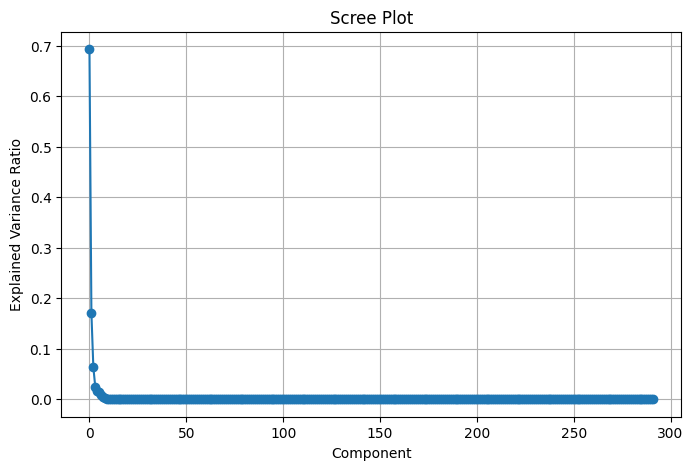

In [50]:
# Plot scree
plt.figure(figsize=(8,5))
plt.plot(pca.explained_variance_ratio_, marker='o')
plt.title("Scree Plot")
plt.xlabel("Component")
plt.ylabel("Explained Variance Ratio")
plt.grid(True)
plt.show()

### Compute cumulative variance

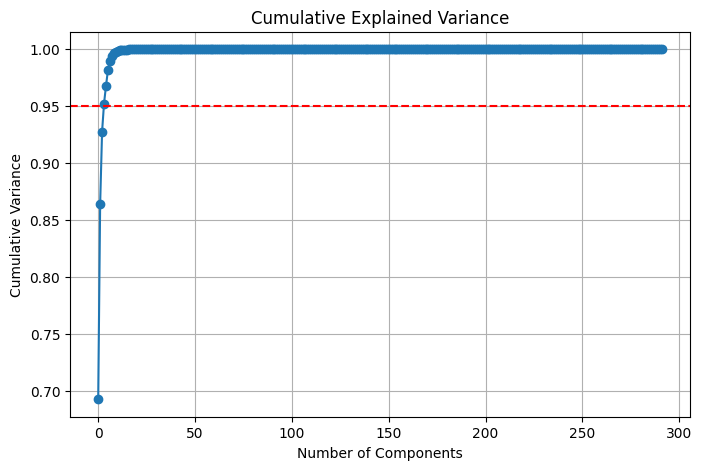

In [51]:
cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(cum_var, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--')
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.grid(True)
plt.show()

### Select the number of PCs based on the highest cumulative variance.

In [52]:
n_components = np.argmax(cum_var >= 0.95) + 1
print("Selected components:", n_components)

Selected components: 4


EMIT's 285 bands are not 285 independent pieces of information. Adjacent wavelength bands are highly correlated — the reflectance at 500nm is almost always very similar to reflectance at 505nm. The actual independent information content is much lower than the number of bands suggests.

This is a well known property of hyperspectral data called spectral redundancy.  
Studies consistently show that most hyperspectral vegetation datasets have fare less intrinsic dimensionality compared the vast number of hyperspectral bands.

Hyperspectral datasets exhibit far lower intrinsic dimensionality than the number of spectral bands suggests, owing to high correlation between adjacent wavelength channels.  

Principal component analysis of vegetation hyperspectral data consistently captures the majority of spectral variance in a small number of components, a finding reported across multiple studies using different sensors and vegetation types.  

**Study-1: https://arxiv.org/html/2512.15544**  
A study on hyperspectral soil moisture estimation found that just two principal components retained more than 99% of total variance from 150 spectral bands.  

**Study-2: https://pmc.ncbi.nlm.nih.gov/articles/PMC11244031/**  
For mangrove species classification using UAV hyperspectral data, the first three principal component bands retained 99.04% of the features from the original image. 

**Study-3: https://www.nature.com/articles/s41598-024-79209-1**
For vegetation classification using hyperspectral imagery, a value of the first 30 bands was often used for vegetation identification because subsequent bands were not very informative.  

**CONCLUSION: Our result of 4 principal components explaining 95% of variance** in the EMIT reflectance data is consistent with this well established property of hyperspectral vegetation datasets.

### Create selected number of PCA components.

In [53]:
pca          = PCA(n_components=n_components)
X_pca        = pca.fit_transform(X_scaled)

# Create PC columns
pc_cols = [f"EMIT_PC{i+1}" for i in range(n_components)]
pc_df   = pd.DataFrame(X_pca, columns=pc_cols, index=train_df.index)

# Combine non-EMIT columns with PCs
pca_output_df = pd.concat([train_df, pc_df], axis=1)

In [54]:
pca_output_df.columns

Index(['dataset', 'plot_id', 'start_date', 'end_date', 'capture_start',
       'capture_end', 'EMIT_selected_date', 'EMIT_granule', 'latitude',
       'longitude',
       ...
       'EMIT_R1424', 'EMIT_R1432', 'EMIT_R1774', 'EMIT_R1781', 'EMIT_R1789',
       'EMIT_R1796', 'EMIT_PC1', 'EMIT_PC2', 'EMIT_PC3', 'EMIT_PC4'],
      dtype='object', length=318)

### Save training data

In [55]:
pca_output_df.to_csv(PCA_TRAIN_CSV, index=False)

In [56]:
len(pca_output_df)

3100

### Save test data

In [57]:
test_df.to_csv(PCA_TEST_CSV, index=False)

In [58]:
len(test_df)

780